In [1]:
import torch
import numpy as np 
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
# make a hexagonal lattice. return an array of shape (2450,2). 
# atom_k has index k = j*nx + i 
# where i = column-index, 0 <= i < nx
# where j = row-index, 0 <= j < ny
def make_triangular_lattice(nx=49, ny=50, spacing=2**(1/6)):
    atom_pos = []

    for j in range(ny):
        for i in range(nx):
            x = spacing * (i + 0.5 * (j % 2))
            y = spacing * (np.sqrt(3) / 2) * j
            atom_pos.append([x, y])

    return np.array(atom_pos, dtype=np.float64)

In [3]:
def remove_central_atom(atom_pos):
    """
    Remove the atom closest to the geometric center.

    Returns:
        atom_pos_defect: positions after removing one atom
        defect_pos: original position of removed atom
        defect_old_idx: index of removed atom in original full lattice
    """
    center = atom_pos.mean(axis=0)

    dist = np.linalg.norm(atom_pos - center[None, :], axis=1)
    defect_old_idx = np.argmin(dist)

    defect_pos = atom_pos[defect_old_idx].copy()

    keep_mask = np.ones(len(atom_pos), dtype=bool)
    keep_mask[defect_old_idx] = False

    atom_pos_defect = atom_pos[keep_mask]

    return atom_pos_defect, defect_pos, defect_old_idx

In [4]:
# find the indices of atoms that are in the vicinity of defect or on the border
# the defcet_region is 3 atoms deep
# the border layer is 3 atoms deep. 
# usng flattened index:index = j * nx + i
# split atoms into:
    # fully atomistic atoms - first/last border_layers rows/columns
    # fully atomistic atoms - first defect_layers rows/columns around defect_idx
    # continuum atoms       - remaining interior atoms
def split_atomistic_continuum(atom_pos_defect, defect_pos, nx=49, ny=50, spacing=2**(1/6),border_layers=3, defect_layers=3):
    atomistic_indices = []
    continuum_indices = []

    # Triangular lattice row spacing. this is the "thickness" of each row so it's used for y-values (not x-values)
    row_spacing = (np.sqrt(3) / 2) * spacing

    for idx in range(len(atom_pos_defect)):
        pos_x,pos_y = atom_pos_defect[idx]
        is_border_atom = (
            pos_x < spacing*border_layers or 
            pos_x >= spacing*(nx - border_layers) or 
            pos_y < row_spacing*border_layers or 
            pos_y >= row_spacing*(ny - border_layers) 
        )

        dist_from_defect = np.linalg.norm(defect_pos - atom_pos_defect[idx])
        is_defect_region_atom = dist_from_defect <= spacing*defect_layers + 1e-10

        if is_border_atom or is_defect_region_atom:
            atomistic_indices.append(idx)
        else:
            continuum_indices.append(idx)

    return (
        np.array(atomistic_indices, dtype=int),
        np.array(continuum_indices, dtype=int),
    )

In [5]:
# place 8 rep-atoms on the square. 
# evenly spaced out lower-left, lower-right, upper-left, upper-right, centre-left, center-right, center-top, center-bottom

def pick_manual_rep_atoms(atom_pos_defect, continuum_indices,frac=0.25):
    
    continuum_atom_pos_defect = atom_pos_defect[continuum_indices]

    xmin, ymin = continuum_atom_pos_defect.min(axis=0)
    xmax, ymax = continuum_atom_pos_defect.max(axis=0)

    cx = 0.5 * (xmin + xmax)
    cy = 0.5 * (ymin + ymax)
    x_width = xmax - xmin
    y_width = ymax - ymin

    # One center + four evenly distributed interior targets
    targets = np.array([
        [xmin + frac * x_width,       ymin + frac * y_width], # lower left
        [xmin + (1 - frac) * x_width, ymin + frac * y_width], # lower right 
        [xmin + frac * x_width,       ymin + (1 - frac) * y_width], # upper left
        [xmin + (1 - frac) * x_width, ymin + (1 - frac) * y_width], # upper right
        
        [cx, ymin + frac * y_width], # mid-left
        [cx, ymin + (1 - frac) * y_width], # mid-right
        [xmin + frac * x_width,       cy], # mid-bottom left
        [xmin + (1-frac) * x_width,       cy], # mid-top
        
    ])

    rep_indices = []

    for target in targets:
        d = np.linalg.norm(continuum_atom_pos_defect - target[None, :], axis=1)
        nearest_local = np.argmin(d)
        rep_indices.append(continuum_indices[nearest_local])

    return np.array(rep_indices, dtype=int), targets

In [6]:
# assign the clusters and equilibrate a little 
def kmeans_from_fixed_reps(atom_pos_defect, continuum_idx, initial_rep_idx, max_iter = 100, tol = 1e-10):
    continuum_atoms = atom_pos_defect[continuum_idx]
    centers = atom_pos_defect[initial_rep_idx].copy()

    n_rep = len(initial_rep_idx)
    history = []

    # assignment step 
    for it in range(max_iter):
        # find distance of all continuum atoms to all rep_atoms 
        dist_matrix = np.linalg.norm(continuum_atoms[:,None,:] - centers[None, :, :], axis=2)

        cluster_idx = np.argmin(dist_matrix,axis=1) 
        # cluster_idx is an array of len continuum_atoms
        # cluster_idx[i]=k means continuum_atoms[i] belongs to rep_atom_k's cluster

        J = np.sum((continuum_atoms - centers[cluster_idx])**2)
        history.append(J)

        # update step 
        new_centers = centers.copy()

        for k in range(n_rep):
            members = continuum_atoms[cluster_idx==k] # all the continuum_atoms that are members of cluster-k

            if len(members) > 0:
                new_centers[k] = members.mean(axis=0)

        # check convergence
        shift = np.linalg.norm(new_centers - centers)
        centers = new_centers
        if shift < tol: break 

        # do one final evaluation
        dist_matrix = np.linalg.norm(continuum_atoms[:,None,:] - centers[None, :, :], axis=2)
        cluster_idx = np.argmin(dist_matrix,axis=1)

        # assign weigths (count the number of atoms in each cluster)
        weights = np.array([np.sum(cluster_idx == k) for k in range(n_rep)],dtype=np.float64)

        # after performing equilibration of cluster-centers, convert cluster-centers to atom_indices of rep_atoms
        final_rep_idx = []
        for k in range(n_rep):
            
            local_members = np.where(cluster_idx==k)[0]
            
            if len(local_members) == 0:
                final_rep_idx.append(initial_rep_idx[k])
                continue

            cluster_atoms = continuum_atoms[local_members]
            d = np.linalg.norm(cluster_atoms - centers[k][None,:],axis=1)
            nearest_local_member = local_members[np.argmin(d)]
            final_rep_idx.append(continuum_idx[nearest_local_member])

        final_rep_idx = np.array(final_rep_idx,dtype=int)
        
    return cluster_idx, centers, final_rep_idx, weights, history

In [7]:
# plot continuum-clusters, atomistic-atoms, cluster-centers, rep-atoms
def plot_partition(atom_pos_defect, atomistic_indices, continuum_indices, cluster_idx, rep_indices, centers,weights,figure_size=(8,7)):
    plt.figure(figsize=figure_size)

    cont_atom_pos = atom_pos_defect[continuum_indices]
    atom_atom_pos = atom_pos_defect[atomistic_indices]
    rep_atom_pos = atom_pos_defect[rep_indices]

    # plot continuum region atoms 
    plt.scatter(cont_atom_pos[:, 0],cont_atom_pos[:, 1],c=cluster_idx,s=8,alpha=0.6,label='continuum region')

    # plot atomistic_regions atoms 
    plt.scatter(atom_atom_pos[:, 0],atom_atom_pos[:, 1],c="black",s=10,label="atomistic region",)

    # plot cluster centers 
    plt.scatter(centers[:, 0],centers[:, 1],c="red",marker="x",s=50,linewidths=1,label="cluster centers",)

    # highlight the atoms that have been assigned as rep_atoms
    plt.scatter(rep_atom_pos[:, 0],rep_atom_pos[:, 1],facecolors="none",edgecolors="red",s=180,linewidths=2,label="rep_atoms",)

    # textbox for weights
    for k, idx in enumerate(rep_indices):
        x, y = atom_pos_defect[idx]
        plt.text(x + 0.2, y + 0.2, f"w={int(weights[k])}", fontsize=9)

    plt.axis("equal")
    plt.legend()
    plt.title("2D kmeans partition: 3 boundary layers, 3 defect layers, 8 representative atoms")
    plt.tight_layout()
    plt.show()


# 2D PINN with Glorot-Init and Swish-Activation
- 4 hidden layers, 23 neurons per layer
- input layer takes (x,y) coords of each atom
- output layer outputs (ux,uy) displacement vector for each atom
- Swish activation
- Glorot initialization of weights
- The `Glorot` initialization does not influence the final error (error relative to LAMMPS simulation). This was demonstrated by executing multiple training runs and measuring the variance in the error


In [8]:
class SwishActivation(nn.Module):
    def forward(self,x):
        return x * torch.sigmoid(x)
        
class PINN2D(nn.Module):

    def GlorotInitWeights(self,m):
        if isinstance(m,nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)
            
    def __init__(self,width=23,depth=4): # 4 hidden layers. 23 neurons per hidden layer
        super().__init__()
    
        # input layer. 2 input features (x,y of atom coords) and 23 output features with Swish activation
        # each atom coordinate is mapped to 23 numbers
        layers = [nn.Linear(2,width),SwishActivation()] 

        # we've already created the first hidden layer above. now add 3 more layers
        # each of these layers have 23 inputs and 23 output features with Swish activation
        for _ in range(depth-1):
            layers += [nn.Linear(width,width),SwishActivation()]

        # add final output layer. 23 inputs and 2 outputs (ux,uy of displacement)
        layers += [nn.Linear(width,2)]

        # make a neural-network of all these layers
        self.net = nn.Sequential(*layers)

        self.apply(self.GlorotInitWeights)

    # forward is a method that gets automatically called when you call the model u_raw = model(x)
    def forward(self,x):
        return self.net(x) # apply the neural network on the input coordination (x,y) of each atom
        

## lennard-jones-6 potential

In [9]:
def LennardJones6(r, epsilon=1.0, sigma=1.0):
    sigma_r_6 = (sigma / r) ** 6
    return 4 * epsilon * (sigma_r_6**2 - sigma_r_6)

def InteractionEnergyLJ(i, atom_pos, cutoff): # energy of atom[i], interaction with all atoms 
    dist_arr = torch.linalg.norm(atom_pos - atom_pos[i], dim=1) # array of distances between atom[i] and all other atoms 
    is_interacting = (dist_arr > 1e-12) & (dist_arr < cutoff) # all the atom-indices that atom[i] interacts with. Ignore self-interaction. Ignore atoms further than cutoff 
    interaction_energy = LennardJones6(dist_arr[is_interacting]) # array of interaction-energy between atom[i] and all other atoms. 
    return 0.5 * torch.sum(interaction_energy) # factor of 0.5 to prevent double-counting

## Problem setup
- 49 x 50 atoms.
- normalized interatomic-spacing $2^{1/6}$
- outermost 3 layers are atomistic
- no point defects
- initial 5 rep-atoms are handpicked and then kmeans-equilibrated
- boundary conditions 
    - atom at origin is fixed in x and y direction
    - atoms along x-axis are constrained in y
    - atom along y-axis are constrained in x

Original atoms: 2450
After point defect: 2449
Removed old index: 1200
Defect position: [26.93908916 23.32993557]
number of atoms 		 2449
atomistic atoms 		 594
continuum atoms 		 1855
initial rep atom indices 	 [ 350  384 2064 2098  367 2081 1183 1265]
final rep atom indices 		 [ 500  529 1919 1948  612 1836 1235 1212]
weights 			 [213. 212. 212. 215. 254. 261. 243. 245.]
sum of weights 			 1855.0


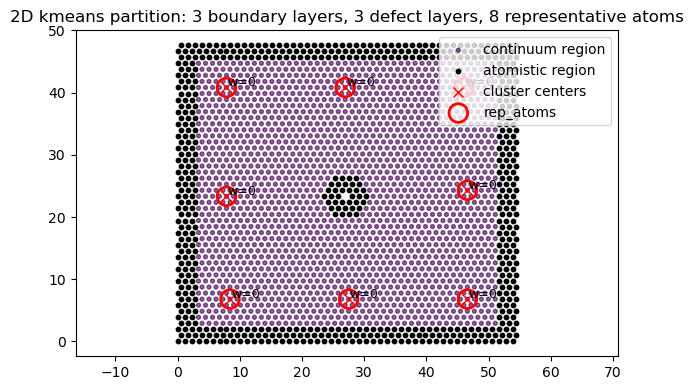

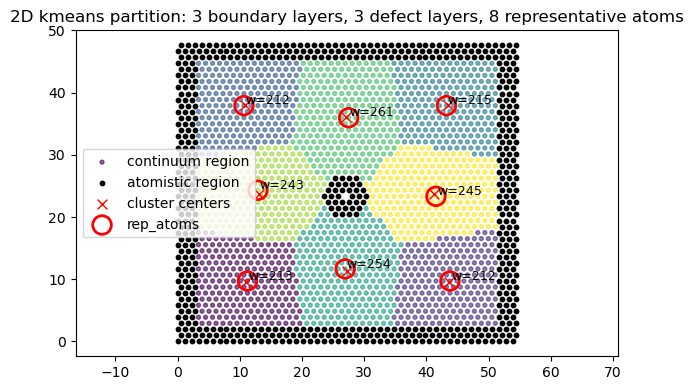

In [10]:

nx, ny = 49, 50
spacing = 2**(1/6)

atom_pos_full = make_triangular_lattice(nx=nx, ny=ny, spacing=spacing)

atom_pos_defect, defect_pos, defect_old_idx = remove_central_atom(atom_pos_full)

print("Original atoms:", len(atom_pos_full))
print("After point defect:", len(atom_pos_defect))
print("Removed old index:", defect_old_idx)
print("Defect position:", defect_pos)

# 3 layers of atoms bordering the square are flagged as atomistic-region
border_layers = 3
defect_layers= 3
atomistic_indices,continuum_indices = split_atomistic_continuum(atom_pos_defect, defect_pos, nx,ny,spacing,border_layers,defect_layers)
continuum_atom_pos = atom_pos_defect[continuum_indices]
atomistic_atom_pos = atom_pos_defect[atomistic_indices]

# manually pick 5 rep_atoms among the continuum atoms 
initial_rep_indices, rep_targets = pick_manual_rep_atoms(atom_pos_defect,continuum_indices,0.10)

# assign continuum-atoms to their clusters, and equilibrate over 100 iterations of kmeans 
cluster_idx, centers, rep_indices, weights, history = kmeans_from_fixed_reps(atom_pos_defect,continuum_indices,initial_rep_indices)

print("number of atoms \t\t", len(atom_pos_defect))
print("atomistic atoms \t\t", len(atomistic_indices))
print("continuum atoms \t\t", len(continuum_indices))
print("initial rep atom indices \t", initial_rep_indices)
print("final rep atom indices \t\t", rep_indices)
print("weights \t\t\t", weights)
print("sum of weights \t\t\t", weights.sum())


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dtype = torch.float64
r0 = torch.tensor(atom_pos_defect, dtype=dtype, device=device) # convert atomic-positions to torch-tensro

# normalize the inputs
mu = r0.mean(dim=0, keepdim=True)
std = r0.std(dim=0, keepdim=True)
r0_norm = (r0 - mu) / std

mask = torch.ones_like(r0, device=device)
u_prescribed = torch.zeros_like(r0, device=device)

tol = 1e-12
on_x_axis = np.abs(atom_pos_defect[:, 1]) < tol # if y == 0 (the first 49 atoms )
on_y_axis = np.abs(atom_pos_defect[:, 0]) < tol # if x == 0 (every 50th atom) 
origin = on_x_axis & on_y_axis

mask[origin, :] = 0.0 # x and y value of mask[i,j] set to 0
mask[on_x_axis, 1] = 0.0 # y-value of mask[i,j] set to 0
mask[on_y_axis, 0] = 0.0 # x-value of mask[i,j] set to 0

plot_partition(atom_pos_defect, atomistic_indices, continuum_indices, [0]*len(continuum_indices), initial_rep_indices, atom_pos_defect[initial_rep_indices],[0 for i in range(initial_rep_indices.size)], figure_size=(6,4))
plot_partition(atom_pos_defect, atomistic_indices, continuum_indices, cluster_idx, rep_indices, centers,weights, figure_size=(6,4))


# Setup the PINN

In [11]:
model = PINN2D().to(device=device, dtype=dtype)
adam_opt = torch.optim.Adam(model.parameters(), lr=1e-4) # optimizer adjusts the weights of the NN

# nearest spacing is 2^(1/6); second-neighbor cutoff for triangular lattice
spacing = 2**(1/6)
cutoff = 1.9 * spacing # this is < third-nearest-neighbor-distance

atomistic_indices_t = torch.tensor(atomistic_indices, dtype=torch.long, device=device)
rep_indices_t = torch.tensor(rep_indices, dtype=torch.long, device=device)
weights_t = torch.tensor(weights, dtype=dtype, device=device)

## Run the PINN - this was executed on `HYDRA`

In [12]:
"""
import json

jsonfilename = "history_2D_with_defect.json"
max_iter = 10
print_every = 1
with open(jsonfilename, "w") as jsonfile:
    jsonfile.write("[\n")
    first_row = True

    for epoch in range(max_iter):
        adam_opt.zero_grad()

        u_raw = model(r0_norm)
        u = mask * u_raw + u_prescribed
        pos = r0 + u

        # approximate QC/PINN energy
        loss = torch.tensor(0.0, dtype=dtype)

        for i in atomistic_indices_t:
            loss = loss + InteractionEnergyLJ(int(i), pos, cutoff)

        for i, w in zip(rep_indices_t, weights_t):
            loss = loss + w * InteractionEnergyLJ(int(i), pos, cutoff)

        # true all-atom energy
        true_energy = torch.tensor(0.0, dtype=dtype)

        for i in atomistic_indices_t:
            true_energy = true_energy + InteractionEnergyLJ(int(i), pos, cutoff)

        for i in continuum_indices:
            true_energy = true_energy + InteractionEnergyLJ(int(i), pos, cutoff)

        loss.backward()
        adam_opt.step()

        row = {
            "epoch": int(epoch),
            "loss": loss.detach().cpu().item(),
            "true_energy": true_energy.detach().cpu().item(),
            "pos": pos.detach().cpu().tolist()
        }

        if not first_row:
            jsonfile.write(",\n")

        jsonfile.write(json.dumps(row))
        first_row = False

        if epoch % print_every == 0:
            print(epoch, float(loss.detach()))
            jsonfile.flush()

    jsonfile.write("\n]\n")
"""

'\nimport json\n\njsonfilename = "history_2D_with_defect.json"\nmax_iter = 10\nprint_every = 1\nwith open(jsonfilename, "w") as jsonfile:\n    jsonfile.write("[\n")\n    first_row = True\n\n    for epoch in range(max_iter):\n        adam_opt.zero_grad()\n\n        u_raw = model(r0_norm)\n        u = mask * u_raw + u_prescribed\n        pos = r0 + u\n\n        # approximate QC/PINN energy\n        loss = torch.tensor(0.0, dtype=dtype)\n\n        for i in atomistic_indices_t:\n            loss = loss + InteractionEnergyLJ(int(i), pos, cutoff)\n\n        for i, w in zip(rep_indices_t, weights_t):\n            loss = loss + w * InteractionEnergyLJ(int(i), pos, cutoff)\n\n        # true all-atom energy\n        true_energy = torch.tensor(0.0, dtype=dtype)\n\n        for i in atomistic_indices_t:\n            true_energy = true_energy + InteractionEnergyLJ(int(i), pos, cutoff)\n\n        for i in continuum_indices:\n            true_energy = true_energy + InteractionEnergyLJ(int(i), pos, cut

## Compare `loss-energy` vs `true-energy` (both calculated by PYTHON)
- `loss-energy` is the coarse-grained energy that is used as the objective function in training the PINN
- `true-energy` is the fully atomistic energy of the system.

In [13]:
# read in the PINN output file evaluated from HYDRA
import json
jsonfilename = "history_2D_with_defect.json"

# Load history
with open(jsonfilename, "r") as jsonfile:
    history = json.load(jsonfile)

# Extract data
epochs = np.array([row["epoch"] for row in history])
loss_energy = np.array([row["loss"] for row in history])
true_energy = np.array([row["true_energy"] for row in history])
pos = np.array([row["pos"] for row in history])

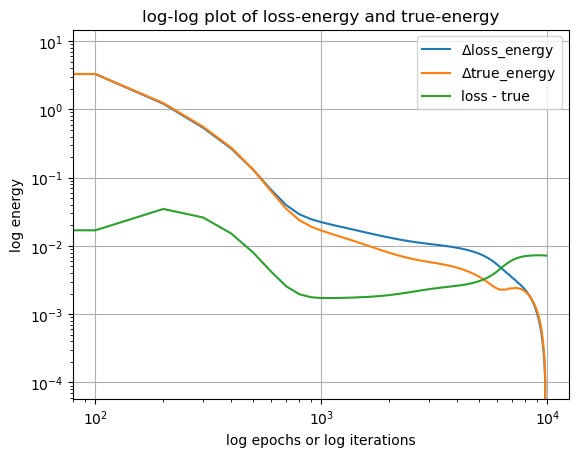

In [14]:
# Plot
plt.figure()
plt.plot(epochs, loss_energy-loss_energy[-1] ,label='$\\Delta$loss_energy')
plt.plot(epochs, true_energy-true_energy[-1] ,label='$\\Delta$true_energy')
plt.plot(epochs, np.abs(loss_energy - true_energy),label='loss - true')
plt.xlabel("log epochs or log iterations")
plt.ylabel("log energy")
plt.title("log-log plot of loss-energy and true-energy")
plt.grid(True)
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.show()

# Compare with LAMMPS

### Helper function for preparing LAMMPS `input-data` of initial position of atoms

In [15]:
def write_lammps_data_2d(filename, pts):
    with open(filename, "w") as f:
        f.write("2D triangular LJ lattice\n\n")
        f.write(f"{len(pts)} atoms\n")
        f.write("1 atom types\n\n")

        xlo, ylo = pts.min(axis=0) - 5.0
        xhi, yhi = pts.max(axis=0) + 5.0

        f.write(f"{xlo:.16f} {xhi:.16f} xlo xhi\n")
        f.write(f"{ylo:.16f} {yhi:.16f} ylo yhi\n")
        f.write("-10.0 10.0 zlo zhi # large z-thickness to prevent interactoins between periodic layers\n\n") # the simulation box will have a large z-thickness and the atoms will be constrained in z-direction

        f.write("Masses\n\n")
        f.write("1 1.0\n\n")

        f.write("Atoms # atomic\n\n")
        for atom_id, (x, y) in enumerate(pts, start=1):
            f.write(f"{atom_id} 1 {x:.16f} {y:.16f} 0.0\n")

### Helper function for converting PYTHON `0-based` index of atoms into LAMMPS `1-based` index

In [16]:
def lammps_id_list(indices):
    """
    Convert 0-based Python atom indices to 1-based LAMMPS atom IDs.
    """
    return " ".join(str(int(i) + 1) for i in indices)

### Helper function for preparing LAMMPS `groups` for boundary-conditions

In [17]:
def make_constraint_groups(atom_pos, tol=1e-12):
    """
    Return atom indices for:
        origin atom
        atoms on x-axis, excluding origin
        atoms on y-axis, excluding origin

    Python indices are 0-based.
    LAMMPS IDs will be index + 1.
    """
    x = atom_pos[:, 0]
    y = atom_pos[:, 1]

    origin = np.where((np.abs(x) < tol) & (np.abs(y) < tol))[0]

    xaxis = np.where((np.abs(y) < tol) & ~(np.abs(x) < tol))[0]
    yaxis = np.where((np.abs(x) < tol) & ~(np.abs(y) < tol))[0]

    if len(origin) != 1:
        raise RuntimeError(f"Expected exactly one origin atom, found {len(origin)}")

    return origin, xaxis, yaxis


### Helper function for writing LAMMPS `input-script` for simulation

In [18]:
def write_lammps_input_2d_no_defect(
    filename,
    data_filename,
    atom_pos,
    spacing=2**(1/6),
    cutoff_factor=1.9,
    dump_every=100,
    traj_filename="relax_2d_traj_with_defect.lammpstrj",
    final_dump_filename="relaxed_2d_with_defect.dump",
    energy_log_filename="relax_2d_energy_with_defect.log",
    force_tol=1.0e-12,
    max_iter=10000,
    max_eval=100000,
):
    """
    Write LAMMPS input script for the 2D triangular LJ no-defect relaxation.
    """

    origin, xaxis, yaxis = make_constraint_groups(atom_pos)

    rc = cutoff_factor * spacing

    with open(filename, "w") as f:
        f.write(f"""# ---------------------------------------------------------------
# LAMMPS input for 2D triangular LJ lattice with point defect
# ---------------------------------------------------------------

# Write LAMMPS screen/log output here.
# The thermo lines in this file contain energy every {dump_every} iterations.
log {energy_log_filename}

# LJ reduced units: epsilon = 1, sigma = 1, mass = 1
units lj

# True 2D simulation. LAMMPS requires z-periodicity for dimension 2.
dimension 2

# Simple atomic particles: id, type, x, y, z
atom_style atomic

# Finite in x and y, periodic in z as required for dimension 2
boundary f f p

# Read initial atom positions
read_data {data_filename}

# Physical cutoff:
# nearest neighbor distance = a
# second neighbor distance  = sqrt(3)*a
# third neighbor distance   = 2*a
# rc = 1.9*a includes 1st and 2nd neighbors, excludes 3rd neighbors
pair_style lj/cut {rc:.16f}
pair_coeff 1 1 1.0 1.0 {rc:.16f}

# Neighbor list settings
neighbor 0.3 bin
neigh_modify every 1 delay 0 check yes

# Keep system in the xy-plane
fix keep2d all enforce2d

# ---------------------------------------------------------------
# Boundary condition groups
# ---------------------------------------------------------------
""")

        f.write(f"group origin id {lammps_id_list(origin)}\n")
        f.write(f"group xaxis id {lammps_id_list(xaxis)}\n")
        f.write(f"group yaxis id {lammps_id_list(yaxis)}\n")

        f.write(f"""
# ---------------------------------------------------------------
# Boundary constraints matching the paper
# origin: fixed in x and y
# x-axis atoms: constrained in y
# y-axis atoms: constrained in x
# ---------------------------------------------------------------

fix fix_origin origin setforce 0.0 0.0 0.0
fix fix_xaxis xaxis setforce NULL 0.0 0.0
fix fix_yaxis yaxis setforce 0.0 NULL 0.0

# Print minimization progress every {dump_every} iterations.
# pe is total potential energy because thermo_modify norm no is used.
thermo {dump_every}
thermo_style custom step pe fnorm fmax
thermo_modify norm no

# Start minimization counter at 0
reset_timestep 0

# Write atom trajectory during minimization
dump traj all custom {dump_every} {traj_filename} id type x y z fx fy fz
dump_modify traj sort id

# Energy minimization
min_style cg
minimize 0.0 {force_tol:.16e} {max_iter} {max_eval}

# Stop trajectory dump
undump traj

# Write final relaxed configuration.
# This is the file you should compare against your final PINN coordinates.
write_dump all custom {final_dump_filename} id type x y z fx fy fz modify sort id
""")

    print(f"Wrote LAMMPS input script: {filename}")
    print(f"Physical LJ cutoff rc = {rc:.16f}")
    print(f"Trajectory dump: {traj_filename}")
    print(f"Final dump: {final_dump_filename}")
    print(f"Energy log: {energy_log_filename}")

In [19]:
nx, ny = 49, 50
spacing = 2**(1/6)

atom_pos_full = make_triangular_lattice(nx=nx, ny=ny, spacing=spacing)
atom_pos_defect, defect_pos, defect_old_idx = remove_central_atom(atom_pos_full)


write_lammps_data_2d(
    filename="lattice_2d_with_defect.data",
    pts=atom_pos_defect,
)

write_lammps_input_2d_no_defect(
    filename="in.relax_2d_with_defect",
    data_filename="lattice_2d_with_defect.data",
    atom_pos=atom_pos_defect,
    spacing=spacing,
    cutoff_factor=1.9,
    dump_every=100,
    traj_filename="relax_2d_traj_with_defect.lammpstrj",
    final_dump_filename="relaxed_2d_with_defect.dump",
    force_tol=1.0e-12,
)

Wrote LAMMPS input script: in.relax_2d_with_defect
Physical LJ cutoff rc = 2.1326778917878086
Trajectory dump: relax_2d_traj_with_defect.lammpstrj
Final dump: relaxed_2d_with_defect.dump
Energy log: relax_2d_energy_with_defect.log


### Helper function for reading LAMMPS output `trajector` file

In [20]:
def read_lammps_trajectory_xy(filename):
    frames = []
    timesteps = []

    with open(filename, "r") as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        if not lines[i].startswith("ITEM: TIMESTEP"):
            i += 1
            continue

        timestep = int(lines[i + 1].strip())
        timesteps.append(timestep)

        if not lines[i + 2].startswith("ITEM: NUMBER OF ATOMS"):
            raise RuntimeError("Unexpected dump format.")

        n_atoms = int(lines[i + 3].strip())

        # Skip box bounds:
        # ITEM: BOX BOUNDS ...
        # x bounds
        # y bounds
        # z bounds
        atom_header_index = i + 8

        if not lines[atom_header_index].startswith("ITEM: ATOMS"):
            raise RuntimeError("Could not find ITEM: ATOMS header.")

        atom_lines_start = atom_header_index + 1
        atom_lines_end = atom_lines_start + n_atoms

        ids = []
        coords = []

        for line in lines[atom_lines_start:atom_lines_end]:
            parts = line.split()
            atom_id = int(parts[0])
            x = float(parts[2])
            y = float(parts[3])

            ids.append(atom_id)
            coords.append([x, y])

        ids = np.array(ids)
        coords = np.array(coords)

        order = np.argsort(ids)
        frames.append(coords[order])

        i = atom_lines_end

    return np.array(timesteps), np.array(frames)

### Helper function for reading in the LAMMPS `energy-logs`

In [21]:
def read_lammps_thermo_energy(log_filename):
    steps = []
    energies = []
    fnorms = []
    fmaxs = []

    in_table = False

    with open(log_filename, "r") as f:
        for line in f:
            parts = line.split()

            if parts[:4] == ["Step", "PotEng", "Fnorm", "Fmax"]:
                in_table = True
                continue

            if in_table:
                if len(parts) != 4:
                    continue

                try:
                    step = int(parts[0])
                    pe = float(parts[1])
                    fnorm = float(parts[2])
                    fmax = float(parts[3])
                except ValueError:
                    continue

                steps.append(step)
                energies.append(pe)
                fnorms.append(fnorm)
                fmaxs.append(fmax)

    return (
        np.array(steps),
        np.array(energies),
        np.array(fnorms),
        np.array(fmaxs),
    )

### Read in the LAMMPS `trajectory` file

In [22]:
timesteps, lammps_frames = read_lammps_trajectory_xy("relax_2d_traj_with_defect.lammpstrj")

print(timesteps.shape)
print(lammps_frames.shape)
# shape: (n_frames, n_atoms, 2)

(101,)
(101, 2449, 2)


## Evaluate the `relative-error` in `displacement-vector-field`
$$ \vec{e(t)}_{disp}  = \frac{\lVert \vec{u(t)}_P - \vec{u(t)}_L \rVert}{\lVert \vec{u(t)}_{L} \rVert} $$
- $\vec{u(t)}_P$ is the displacement field predicted by the PINN model at epoch $t$
- $\vec{u(t)}_L$ is the displacement field evaluated by the LAMMPS simulation at iteration $t$

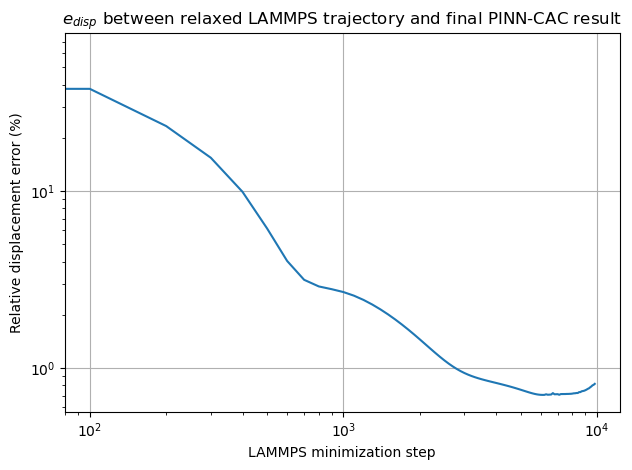

In [23]:
def relative_displacement_error(u_ref, u_pred):
    return np.linalg.norm(u_ref - u_pred) / np.linalg.norm(u_ref)

errors = []

for i in range(1,len(pos)):
    u_lammps = lammps_frames[i] - atom_pos_defect
    u_pinn = pos[i]  - atom_pos_defect
    err = relative_displacement_error(u_lammps,u_pinn)
    errors.append(err)
errors = np.array(errors)

plt.figure()
plt.plot(np.arange(len(errors))*100, 100*errors)
plt.xlabel("LAMMPS minimization step")
plt.ylabel("Relative displacement error (%)")
plt.title("$e_{disp}$ between relaxed LAMMPS trajectory and final PINN-CAC result")
plt.grid(True)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.show()

In [24]:
u_lammps_mags = np.linalg.norm(lammps_frames-atom_pos_defect,axis=2)
u_pinn_mags = np.linalg.norm(pos-atom_pos_defect,axis=2)
relative_err_mags = (np.linalg.norm(lammps_frames[1:]-pos,axis=2)/np.linalg.norm(lammps_frames[1:],axis=2))

/tmp/ipykernel_2846469/3137478258.py:3: RuntimeWarning: invalid value encountered in divide
  relative_err_mags = (np.linalg.norm(lammps_frames[1:]-pos,axis=2)/np.linalg.norm(lammps_frames[1:],axis=2))


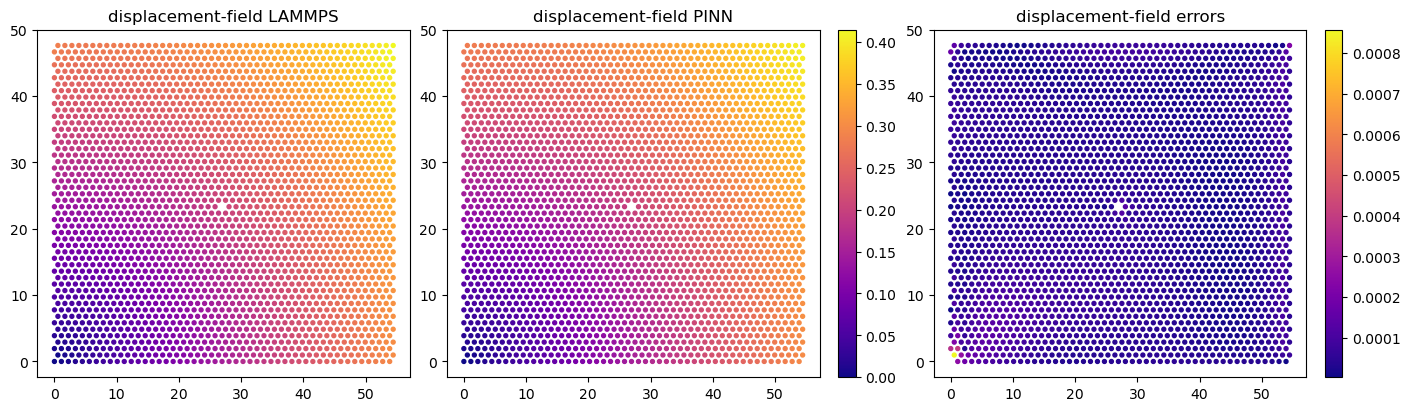

In [25]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4), layout='constrained')

vmin = np.min([np.min(u_pinn_mags[-1]),np.min(u_lammps_mags[-1])])
vmax = np.max([np.max(u_pinn_mags[-1]),np.max(u_lammps_mags[-1])])

scatter_lammps = ax1.scatter(atom_pos_defect[:, 0],atom_pos_defect[:, 1],c=u_lammps_mags[-1],cmap='plasma',s=8,alpha=1,label='LAMMPS',vmin=vmin,vmax=vmax)
scatter_pinn = ax2.scatter(atom_pos_defect[:, 0],atom_pos_defect[:, 1],c=u_pinn_mags[-1],cmap='plasma',s=8,alpha=1,label='PINN',vmin=vmin,vmax=vmax)
cbar_shared = fig.colorbar(scatter_pinn)
ax1.set_title("displacement-field LAMMPS")
ax2.set_title("displacement-field PINN")

scatter_error = ax3.scatter(atom_pos_defect[:, 0],atom_pos_defect[:, 1],c=relative_err_mags[-1],cmap='plasma',s=8,alpha=1,label='error')
cbar_error = fig.colorbar(scatter_error)
ax3.set_title("displacement-field errors")

plt.show()

## Evaluate the `relative-error` in `bond-length-vector`
$$ \vec{err(t)}_{bond}  = \frac{\lVert \vec{b(t)}_P - \vec{b(t)}_L \rVert}{\lVert \vec{b(t)}_{L} \rVert} $$
- bond-length is a vector $\vec{b} = \{b_1, b_2, b_3, ... b_{N_A} \}$ where $b_i$ is the bond-length of atom $i$
- Bond-Length of atom $a$ is given by $\frac{1}{2} \Sigma_{b} \lVert \vec{r_a(t)} - \vec{r_b(t)} \rVert$ where the summation is over all atoms $b$ in the first-nearest-neighbor of atom $a$
- $\vec{b(t)}_P$ is the bond-length vector predicted by the PINN model at epoch $t$
- $\vec{b(t)}_L$ is the bond-length vector evaluated by the LAMMPS simulation at iteration $t$
- NOTE: first-neighbors are evaluated at the referernce configuration (zeroth iteration) 

In [26]:
# the first-neighbor-list is evaluated on the initial configuration. 
def build_first_neighbor_list(reference_pos, spacing=2**(1/6), tol=1e-6):
    neighs = []

    for idx in range(len(reference_pos)):
        dist = np.linalg.norm(reference_pos - reference_pos[idx], axis=1)

        nbrs = np.where(
            (dist > 1e-12) & (np.abs(dist - spacing) < tol)
        )[0]

        neighs.append(nbrs)

    return neighs


def bond_length_vector_from_neighs(pos, neighs):
    b = np.zeros(len(pos), dtype=np.float64)

    for i, nbrs in enumerate(neighs):
        if len(nbrs) == 0:
            b[i] = 0.0
            continue

        distances = np.linalg.norm(pos[nbrs] - pos[i], axis=1)
        b[i] = 0.5 * np.sum(distances)

    return b


def relative_bond_length_error(pos0, pos_lammps, pos_pinn, spacing=2**(1/6), tol=1e-6):
    neighs = build_first_neighbor_list(pos0, spacing=spacing, tol=tol)

    b_lammps = bond_length_vector_from_neighs(pos_lammps, neighs)
    b_pinn = bond_length_vector_from_neighs(pos_pinn, neighs)

    err = np.linalg.norm(b_lammps - b_pinn) / np.linalg.norm(b_lammps)

    return err, b_lammps, b_pinn

In [27]:
# find the bond-length-vectors at all times
bond_lengths_lammps = []
bond_lengths_pinn = []
bond_lengths_errors = []
for i in range(len(pos)):
    err_bond, b_lammps, b_pinn = relative_bond_length_error(
        pos0=atom_pos_defect,
        pos_lammps=lammps_frames[i+1],
        pos_pinn=pos[i],
        spacing=2**(1/6),
    )
    bond_lengths_errors.append(err_bond)
    bond_lengths_lammps.append(b_lammps)
    bond_lengths_pinn.append(b_pinn)

bond_lengths_errors = np.array(bond_lengths_errors)
bond_lengths_lammps = np.array(bond_lengths_lammps)
bond_lengths_pinn = np.array(bond_lengths_pinn)

print(f"bond-length error at final iteration/epoch = {100 * bond_lengths_errors[-1]:.6f}%")

bond-length error at final iteration/epoch = 0.021207%


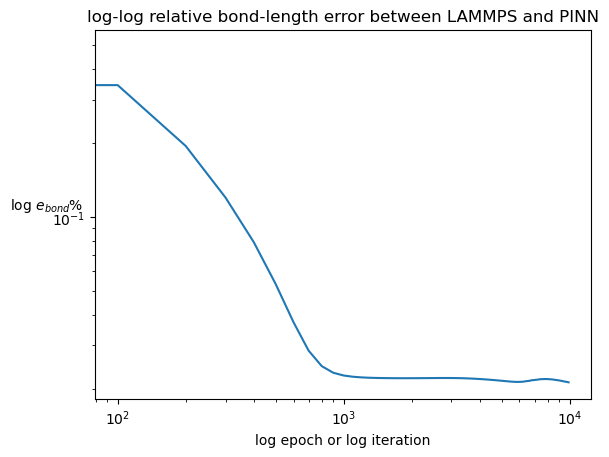

In [28]:
plt.plot(epochs,100*bond_lengths_errors)
plt.yscale('log')
plt.xscale('log')
plt.title('log-log relative bond-length error between LAMMPS and PINN')
plt.xlabel('log epoch or log iteration')
plt.ylabel('log $e_{bond}$%',rotation=0)
plt.show()

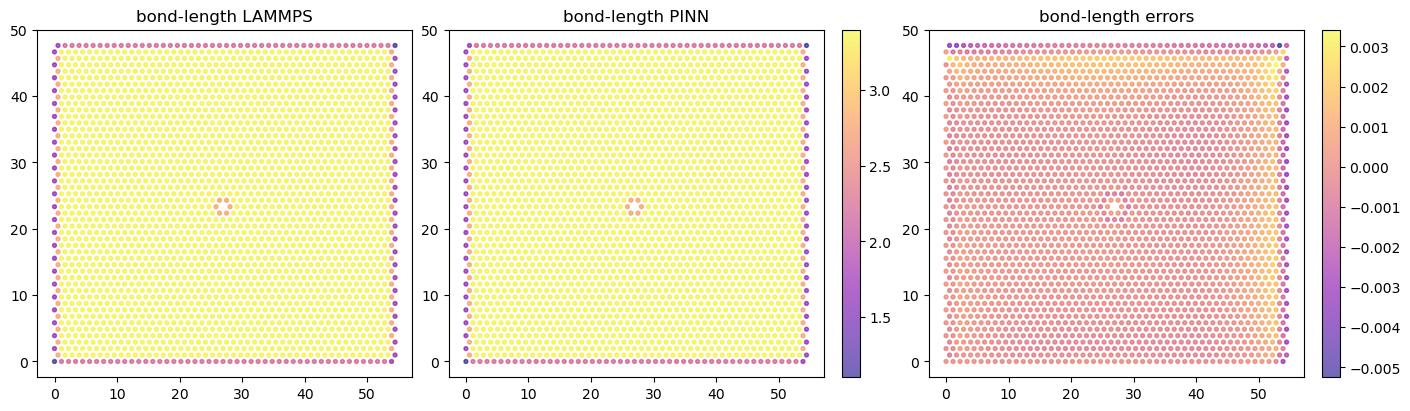

In [29]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4), layout='constrained')
vmin = np.min([np.min(bond_lengths_lammps),np.min(bond_lengths_pinn)])
vmax = np.max([np.max(bond_lengths_lammps),np.max(bond_lengths_pinn)])
scatter_lammps = ax1.scatter(atom_pos_defect[:, 0],atom_pos_defect[:, 1],c=bond_lengths_lammps[-1],cmap='plasma',s=8,alpha=0.6,label='LAMMPS',vmin=vmin,vmax=vmax)
scatter_pinn = ax2.scatter(atom_pos_defect[:, 0],atom_pos_defect[:, 1],c=bond_lengths_pinn[-1],cmap='plasma',s=8,alpha=0.6,label='PINN',vmin=vmin,vmax=vmax)
cbar_shared = fig.colorbar(scatter_pinn)
ax1.set_title("bond-length LAMMPS")
ax2.set_title("bond-length PINN")

scatter_error = ax3.scatter(atom_pos_defect[:, 0],atom_pos_defect[:, 1],c=bond_lengths_pinn[-1]-bond_lengths_lammps[-1],cmap='plasma',s=8,alpha=0.6,label='error')
cbar_error = fig.colorbar(scatter_error)
ax3.set_title("bond-length errors")

plt.show()

## Evaluate the `relative-error` in `total-energy`
$$ err(t)_{E}  = \frac{\lVert E(t)_P - E(t)_L \rVert}{\lVert E(t)_L \rVert} $$
- $E(t)_P$ is the total `coarse-grained-energy` predicted by the PINN model at epoch $t$. 
- $E(t)_L$ is the total `atomistic-energy` evaluated by the LAMMPS simulation at iteration $t$
- The `coarse-grained-energy` is the `loss` function in the PINN. 

### Read in the LAMMPS `energy-logs`

In [30]:
steps, pe, fnorm, fmax = read_lammps_thermo_energy("relax_2d_energy_with_defect.log")

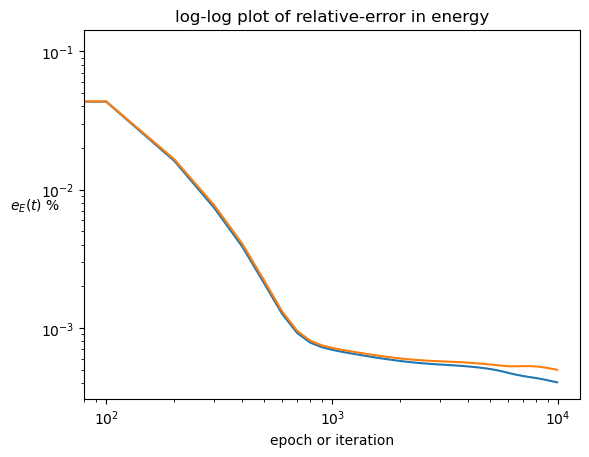

In [31]:
energy_err = np.abs(loss_energy - pe[1:])/np.abs(pe[1:])
energy_err2 = np.abs(true_energy - pe[1:])/np.abs(pe[1:])
plt.plot(epochs,energy_err*100,label='loss-error')
plt.plot(epochs,energy_err2*100,label='true-error')
plt.yscale('log')
plt.xscale('log')
plt.title('log-log plot of relative-error in energy')
plt.ylabel('$e_{E}(t)$ %',rotation=0)
plt.xlabel('epoch or iteration')
plt.show()